# Online Retail II: Customer Segmentation, CLV Prediction & Recommendation System

**Project:** Predictive Customer Analytics: Segmentation, CLV Prediction and Recommendation System
**Dataset:** Online Retail II (UCI Machine Learning Repository / Kaggle)

In this notebook I cleaned the raw data, ran EDA, built RFM segments, clustered customers with K-Means and DBSCAN, predicted CLV with BG/NBD and Gamma-Gamma, and built a recommendation system combining collaborative and content-based filtering.

## 1. Setup

In [1]:
!pip install -q lifetimes kagglehub

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
plt.rcParams['figure.dpi'] = 100
os.makedirs('charts', exist_ok=True)

## 2. Load Data

I set this up to check a few places for the dataset: first Kaggle's input folder, then a `kagglehub` download, and finally a local copy of `online_retail_II.csv` if neither of those works.

In [3]:
import os

RAW_PATH = None
for p in ['/kaggle/input/online-retail-ii-uci/online_retail_II.csv']:
    if os.path.exists(p):
        RAW_PATH = p
        break

if RAW_PATH is None:
    try:
        import kagglehub
        path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")
        for f in os.listdir(path):
            if f.endswith('.csv'):
                RAW_PATH = os.path.join(path, f)
                break
    except Exception as e:
        print('kagglehub unavailable:', e)

if RAW_PATH is None and os.path.exists('online_retail_II.csv'):
    RAW_PATH = 'online_retail_II.csv'

assert RAW_PATH is not None, "Could not locate online_retail_II.csv, upload it manually and set RAW_PATH."
print('Loading from:', RAW_PATH)

raw = pd.read_csv(RAW_PATH, encoding='latin1', parse_dates=['InvoiceDate'])
print('Raw shape:', raw.shape)
raw.head()

  0%|          | 0.00/14.5M [00:00<?, ?B/s]

  7%|▋         | 1.00M/14.5M [00:01<00:20, 689kB/s]

 14%|█▍        | 2.00M/14.5M [00:01<00:09, 1.38MB/s]

 21%|██        | 3.00M/14.5M [00:01<00:05, 2.19MB/s]

 34%|███▍      | 5.00M/14.5M [00:02<00:02, 4.10MB/s]

...

100%|██████████| 14.5M/14.5M [00:02<00:00, 5.51MB/s]

Extracting files...


Loading from: ~/.cache/kagglehub/datasets/mashlyn/online-retail-ii-uci/versions/3/online_retail_II.csv


Raw shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
print(raw.dtypes)
print()
print('Nulls per column:')
print(raw.isna().sum())
print()
print('Date range:', raw['InvoiceDate'].min(), '-', raw['InvoiceDate'].max())

Invoice                   str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

Nulls per column:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Date range: 2009-12-01 07:45:00 - 2011-12-09 12:50:00


## 3. Data Cleaning

Here's what I removed and why:
- Rows with `Price <= 0`: these are junk/write-off entries (`damages`, `check`, `found`, `?`, `thrown away`), not real sales.
- The internal test SKUs `TEST001` / `TEST002`, literally labelled *"THIS IS A TEST PRODUCT."*

And what I kept: shipping/fee/admin codes (`POST`, `DOT`, `BANK CHARGES`, `AMAZONFEE`, `M`, `D`, `S`, `C2`, `ADJUST`, `PADS`, `CRUK`) and gift vouchers. They're real revenue that customers actually paid, so I keep them in. I also kept cancellations (invoices starting with `'C'`) instead of dropping them; I flag them with `IsCancellation` and let them net out on their own in the revenue and RFM numbers later.

In [5]:
# Inspect the junk rows being removed
price0 = raw[raw['Price'] <= 0]
print('Price <= 0 rows:', len(price0))
print(price0['Description'].value_counts().head(10))

Price <= 0 rows: 6207
Description
check                    162
?                         92
damages                   84
damaged                   81
found                     28
missing                   27
sold as set on dotcom     20
Damaged                   17
adjustment                16
OWL DOORSTOP              15
Name: count, dtype: int64


In [6]:
test_codes = ['TEST001', 'TEST002']
mask_test = raw['StockCode'].astype(str).isin(test_codes)
print('Test SKU rows:', mask_test.sum())
print(raw[mask_test][['Invoice','StockCode','Description','Quantity','Price']].head())

Test SKU rows: 17
      Invoice StockCode              Description  Quantity  Price
27994  491725   TEST001  This is a test product.        10    4.5
28251  491742   TEST001  This is a test product.         5    4.5
28254  491744   TEST001  This is a test product.         5    4.5
39398  492718   TEST001  This is a test product.         5    4.5
39411  492722   TEST002  This is a test product.         1    1.0


In [7]:
# Confirm which admin/fee codes are being kept (real revenue, not junk)
admin_codes = ['POST','DOT','M','C2','D','S','BANK CHARGES','ADJUST','ADJUST2','AMAZONFEE','PADS','CRUK']
gift_codes = [c for c in raw['StockCode'].astype(str).unique() if c.startswith('gift_')]
kept_codes = admin_codes + gift_codes
kept_rows = raw[raw['StockCode'].astype(str).isin(kept_codes)]
print('Admin/fee/voucher rows KEPT:', len(kept_rows))
print('Revenue represented by these rows:', round((kept_rows['Quantity']*kept_rows['Price']).sum(), 2))
print(kept_rows['StockCode'].value_counts())

Admin/fee/voucher rows KEPT: 5902
Revenue represented by these rows: 50984.49
StockCode
POST            2122
DOT             1446
M               1421
C2               282
D                177
S                104
BANK CHARGES     102
ADJUST            67
AMAZONFEE         43
gift_0001_20      29
gift_0001_30      29
PADS              19
gift_0001_10      16
CRUK              16
gift_0001_50       8
gift_0001_40       7
gift_0001_80       4
gift_0001_70       3
ADJUST2            3
gift_0001_60       2
gift_0001_90       2
Name: count, dtype: int64


In [8]:
# Apply the cleaning rule
mask_price0 = raw['Price'] <= 0
to_remove = mask_test | mask_price0

clean = raw[~to_remove].copy()
print('Raw rows:', len(raw))
print('Removed:', to_remove.sum(), '(test SKUs:', mask_test.sum(), ', junk price<=0:', mask_price0.sum(), ')')
print('Clean rows:', len(clean))

clean['IsCancellation'] = clean['Invoice'].astype(str).str.startswith('C')
clean['TotalPrice'] = clean['Quantity'] * clean['Price']

# Outlier-aware capped columns (0.1th/99.9th percentile): kept for reference, NOT used in TotalPrice
q_low, q_high = clean['Quantity'].quantile([0.001, 0.999])
p_low, p_high = clean['Price'].quantile([0.001, 0.999])
clean['Quantity_capped'] = clean['Quantity'].clip(q_low, q_high)
clean['Price_capped'] = clean['Price'].clip(p_low, p_high)

print()
print('IsCancellation counts:', clean['IsCancellation'].value_counts().to_dict())
clean.head()

Raw rows: 1067371
Removed: 6221 (test SKUs: 17 , junk price<=0: 6207 )
Clean rows: 1061150



IsCancellation counts: {False: 1041660, True: 19490}


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancellation,TotalPrice,Quantity_capped,Price_capped
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4,12,6.95
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,12,6.75
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,12,6.75
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.8,48,2.10
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.0,24,1.25


In [9]:
# Customer-level dataset (drop rows with no Customer ID, used for all customer-level modeling)
cust = clean.dropna(subset=['Customer ID']).copy()
cust['Customer ID'] = cust['Customer ID'].astype(int)
print('Customer-level rows:', len(cust), '| unique customers:', cust['Customer ID'].nunique())
print('Countries dropped entirely by this filter (anonymous-only countries):',
      set(clean['Country'].unique()) - set(cust['Country'].unique()))

Customer-level rows: 824279 | unique customers: 5939


Countries dropped entirely by this filter (anonymous-only countries): {'Hong Kong', 'Bermuda'}


### 3.1 Other data quality issues I found (didn't fix these here)

In [10]:
# Duplicate rows
dup_mask = clean.duplicated(subset=['Invoice','StockCode','Quantity','InvoiceDate','Price','Customer ID'], keep=False)
print('Rows involved in exact duplicates:', dup_mask.sum(), f"({dup_mask.mean()*100:.1f}%)")

# Same StockCode -> multiple Descriptions (spelling/typo variants)
desc_per_code = clean.groupby('StockCode')['Description'].nunique()
print('StockCodes with >1 distinct Description:', (desc_per_code > 1).sum())

# Case-duplicated StockCodes (e.g. 15056bl vs 15056BL, same product)
case_groups = clean.groupby(clean['StockCode'].astype(str).str.upper())['StockCode'].nunique()
print('StockCode groups with case variants:', (case_groups > 1).sum())

# Fake "countries"
print('Non-geographic country labels present:', [c for c in clean['Country'].unique() if c in ('Unspecified','European Community')])

# Encoding artifact
enc_issue = clean['Description'].dropna().astype(str).str.contains('Â£').sum()
print('Rows with encoding artifact (Â£ instead of £):', enc_issue)

# Customer 12346: known internal/test account (uses TEST SKU + a same-day fully-cancelled 74,215-unit order)
c12346 = clean[clean['Customer ID'] == 12346]
print()
print('Customer 12346 net revenue (test/internal account):', round(c12346['TotalPrice'].sum(), 2))

Rows involved in exact duplicates: 66872 (6.3%)
StockCodes with >1 distinct Description: 648


StockCode groups with case variants: 171
Non-geographic country labels present: ['Unspecified', 'European Community']


Rows with encoding artifact (Â£ instead of £): 79

Customer 12346 net revenue (test/internal account): -263.68


## 4. Exploratory Data Analysis

In [11]:
non_product_codes = ['POST','DOT','M','C2','D','S','BANK CHARGES','ADJUST','ADJUST2','AMAZONFEE','PADS','CRUK']
non_product_codes += [c for c in clean['StockCode'].astype(str).unique() if c.startswith('gift_')]

clean['InvoiceDate'] = pd.to_datetime(clean['InvoiceDate'])
sales = clean[~clean['IsCancellation']]
products_only = sales[~sales['StockCode'].astype(str).isin(non_product_codes)]

total_rev = sales['TotalPrice'].sum()
print('Total revenue (ex-cancellations):', round(total_rev, 2))
print('Orders (unique invoices):', sales['Invoice'].nunique())
print('Customers:', sales['Customer ID'].nunique())
print('Average order value:', round(sales.groupby('Invoice')['TotalPrice'].sum().mean(), 2))
print('Unique products sold (excl. admin/fee/voucher codes):', products_only['StockCode'].nunique())

Total revenue (ex-cancellations): 20972368.57
Orders (unique invoices): 40067
Customers: 5878
Average order value: 523.43
Unique products sold (excl. admin/fee/voucher codes): 4897


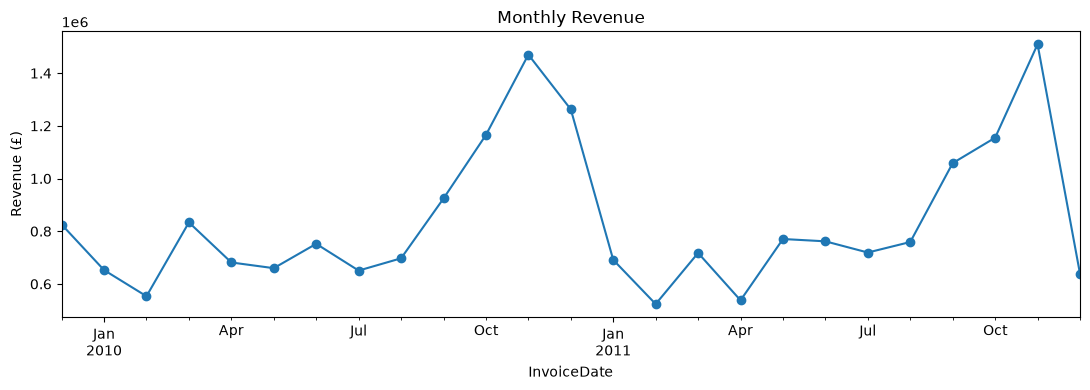

Best month: 2011-11 1509496.33
Worst month: 2011-02 523631.89


In [12]:
monthly = sales.set_index('InvoiceDate').resample('ME')['TotalPrice'].sum()
fig, ax = plt.subplots(figsize=(11,4))
monthly.plot(ax=ax, marker='o')
ax.set_title('Monthly Revenue')
ax.set_ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

print('Best month:', monthly.idxmax().strftime('%Y-%m'), round(monthly.max(),2))
print('Worst month:', monthly.idxmin().strftime('%Y-%m'), round(monthly.min(),2))

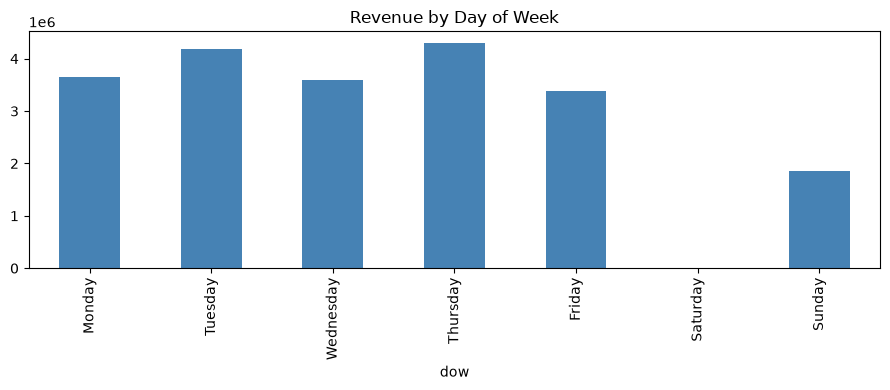

In [13]:
by_dow = sales.copy()
by_dow['dow'] = by_dow['InvoiceDate'].dt.day_name()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_rev = by_dow.groupby('dow')['TotalPrice'].sum().reindex(order)

fig, ax = plt.subplots(figsize=(9,4))
dow_rev.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Revenue by Day of Week')
plt.tight_layout()
plt.show()

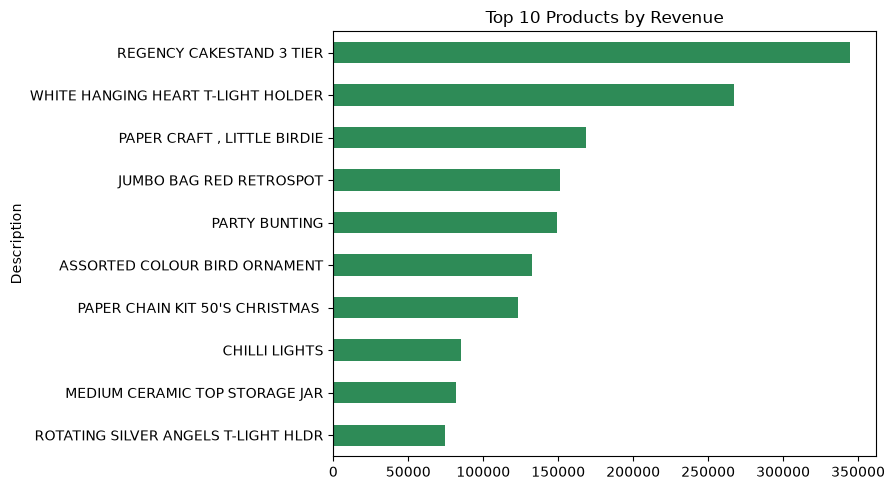

In [14]:
top_products = products_only.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(9,5))
top_products.sort_values().plot(kind='barh', ax=ax, color='seagreen')
ax.set_title('Top 10 Products by Revenue')
plt.tight_layout()
plt.show()

In [15]:
country_rev = sales.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
pct = (country_rev / country_rev.sum() * 100).round(2)
print(pct.head(6))
print('Countries contributing <0.1% of revenue:', (pct < 0.1).sum(), 'of', len(pct))

Country
United Kingdom    85.21
EIRE               3.17
Netherlands        2.64
Germany            2.06
France             1.70
Australia          0.81
Name: TotalPrice, dtype: float64
Countries contributing <0.1% of revenue: 22 of 43


In [16]:
csales = cust[~cust['IsCancellation']]
orders_per_cust = csales.groupby('Customer ID')['Invoice'].nunique()
repeat_pct = (orders_per_cust >= 2).mean() * 100
print(f'Repeat buyers: {repeat_pct:.1f}%  |  One-time buyers: {100-repeat_pct:.1f}%')

rev_per_cust = csales.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False)
n = len(rev_per_cust)
top10 = rev_per_cust.head(int(n*0.10)).sum() / rev_per_cust.sum() * 100
top20 = rev_per_cust.head(int(n*0.20)).sum() / rev_per_cust.sum() * 100
print(f'Top 10% of customers generate {top10:.1f}% of revenue')
print(f'Top 20% of customers generate {top20:.1f}% of revenue')
print()
print('-> Strong Pareto pattern: justifies RFM segmentation and CLV modeling.')

Repeat buyers: 72.4%  |  One-time buyers: 27.6%
Top 10% of customers generate 63.9% of revenue
Top 20% of customers generate 77.2% of revenue

-> Strong Pareto pattern: justifies RFM segmentation and CLV modeling.


## 5. RFM Feature Engineering

I defined:
- **Recency** = days since the last real (non-cancelled) purchase
- **Frequency** = number of distinct non-cancellation invoices
- **Monetary** = net revenue per customer (sales minus cancellations)

Using the net number instead of gross sales is what fixes the Customer 12346 outlier automatically; I didn't need to manually exclude them.

In [17]:
snapshot_date = cust['InvoiceDate'].max() + pd.Timedelta(days=1)
print('Snapshot date:', snapshot_date)

sales_c = cust[~cust['IsCancellation']]
recency = sales_c.groupby('Customer ID')['InvoiceDate'].max().apply(lambda d: (snapshot_date - d).days)
frequency = sales_c.groupby('Customer ID')['Invoice'].nunique()
monetary = cust.groupby('Customer ID')['TotalPrice'].sum()   # NET of cancellations

rfm = pd.DataFrame({'Recency': recency, 'Frequency': frequency, 'Monetary': monetary}).reset_index()
rfm = rfm.dropna(subset=['Recency','Frequency'])

print('RFM table shape:', rfm.shape)
print(rfm.describe())
print()
print('Customer 12346 sanity check (should be near-zero, not an outlier):')
print(rfm[rfm['Customer ID']==12346])

Snapshot date: 2011-12-10 12:50:00


RFM table shape: (5878, 4)
        Customer ID      Recency    Frequency       Monetary
count   5878.000000  5878.000000  5878.000000    5878.000000
mean   15315.313542   201.331916     6.287683    2842.657334
std     1715.572666   209.338707    13.009300   14040.153917
min    12346.000000     1.000000     1.000000  -10953.500000
25%    13833.250000    26.000000     1.000000     335.027500
50%    15314.500000    96.000000     3.000000     862.745000
75%    16797.750000   380.000000     7.000000    2217.362500
max    18287.000000   739.000000   398.000000  598215.220000

Customer 12346 sanity check (should be near-zero, not an outlier):
   Customer ID  Recency  Frequency  Monetary
0        12346    326.0        3.0   -263.68


## 6. RFM Scoring & Rule-Based Segmentation

In [18]:
rfm['R_score'] = pd.qcut(rfm['Recency'].rank(method='first', ascending=False), 5, labels=[1,2,3,4,5]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_sum'] = rfm[['R_score','F_score','M_score']].sum(axis=1)

def segment(row):
    r, f = row['R_score'], row['F_score']
    if r>=4 and f>=4: return 'Champions'
    if r>=3 and f>=3: return 'Loyal Customers'
    if r>=4 and f<=2: return 'New Customers'
    if r==3 and f<=2: return 'Potential Loyalists'
    if r<=2 and f>=4: return "Can't Lose Them"
    if r<=2 and f==3: return 'At Risk'
    if r<=2 and f<=2: return 'Hibernating/Lost'
    return 'Others'

rfm['Segment'] = rfm.apply(segment, axis=1)

seg_summary = rfm.groupby('Segment').agg(
    Customers=('Customer ID','count'), Avg_Recency=('Recency','mean'),
    Avg_Frequency=('Frequency','mean'), Avg_Monetary=('Monetary','mean'),
    Total_Revenue=('Monetary','sum')
).sort_values('Total_Revenue', ascending=False)
seg_summary['Pct_Customers'] = (seg_summary['Customers']/len(rfm)*100).round(1)
seg_summary['Pct_Revenue'] = (seg_summary['Total_Revenue']/rfm['Monetary'].sum()*100).round(1)
seg_summary.round(1)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Pct_Customers,Pct_Revenue
Segment,,,,,,,
Champions,1474,20.2,15.7,8017.0,11816991.2,25.1,70.7
Loyal Customers,1228,78.3,5.4,2004.3,2461226.0,20.9,14.7
Can't Lose Them,354,343.6,7.5,2718.8,962460.8,6.0,5.8
Hibernating/Lost,1526,458.7,1.3,391.4,597308.8,26.0,3.6
At Risk,471,387.9,3.0,953.8,449246.7,8.0,2.7
New Customers,440,27.9,1.5,507.0,223062.8,7.5,1.3
Potential Loyalists,385,106.1,1.4,516.5,198843.5,6.5,1.2


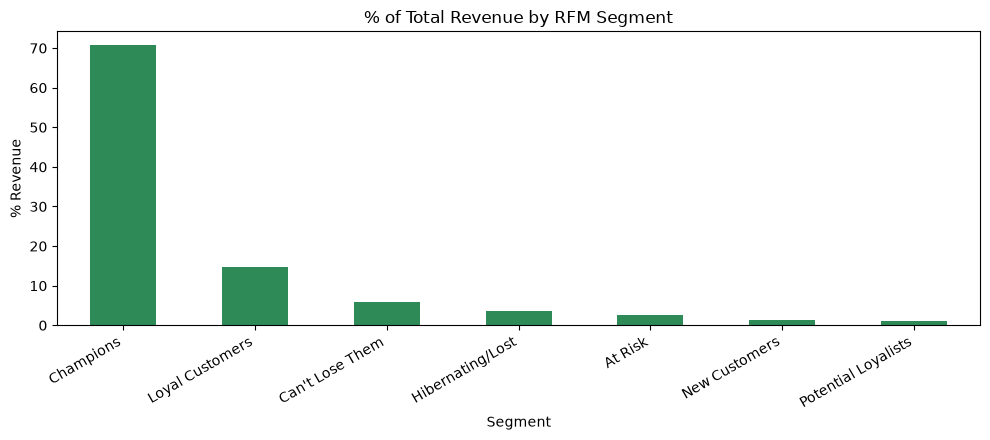

In [19]:
fig, ax = plt.subplots(figsize=(10,4.5))
seg_summary['Pct_Revenue'].plot(kind='bar', ax=ax, color='seagreen')
ax.set_title('% of Total Revenue by RFM Segment')
ax.set_ylabel('% Revenue')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('charts/segment_bars.png', bbox_inches='tight')
plt.show()

## 7. Clustering (K-Means & DBSCAN)

Before clustering, I log-transformed and standardized the RFM features. I had to shift Monetary first since about 24 customers have negative net spend from heavy returns, and you can't take a log of a negative number.

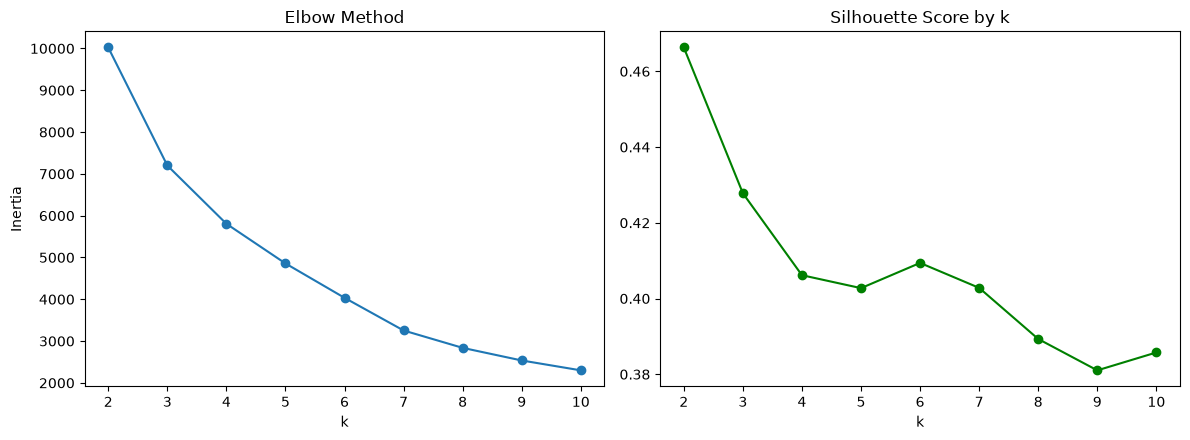

2 10023.2 0.4663
3 7200.4 0.4278
4 5806.0 0.4062
5 4857.1 0.4027
6 4034.7 0.4094
7 3253.1 0.4028
8 2837.5 0.3893
9 2535.7 0.381
10 2299.6 0.3858


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

m_shift = rfm['Monetary'] - rfm['Monetary'].min() + 1
X = pd.DataFrame({
    'Recency_log': np.log1p(rfm['Recency']),
    'Frequency_log': np.log1p(rfm['Frequency']),
    'Monetary_log': np.log1p(m_shift)
})
X_scaled = StandardScaler().fit_transform(X)

inertias, silhouettes = {}, {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias[k] = km.inertia_
    silhouettes[k] = silhouette_score(X_scaled, labels)

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
axes[0].plot(list(inertias.keys()), list(inertias.values()), marker='o')
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(silhouettes.keys()), list(silhouettes.values()), marker='o', color='green')
axes[1].set_title('Silhouette Score by k'); axes[1].set_xlabel('k')
plt.tight_layout()
plt.savefig('charts/elbow_silhouette.png', bbox_inches='tight')
plt.show()

for k in range(2,11):
    print(k, round(inertias[k],1), round(silhouettes[k],4))

I went with **k=4** here. The elbow curve flattens out noticeably after 4, and the silhouette score (0.406) is close to the best score overall (0.466 at k=2) but actually gives me segments I can act on. k=2 alone was too coarse to be useful for anything.

In [21]:
K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm['KMeans_Cluster'] = km.fit_predict(X_scaled)

profile = rfm.groupby('KMeans_Cluster').agg(
    Customers=('Customer ID','count'), Avg_Recency=('Recency','mean'),
    Avg_Frequency=('Frequency','mean'), Avg_Monetary=('Monetary','mean'),
    Total_Revenue=('Monetary','sum')
).round(1)
profile['Pct_Customers'] = (profile['Customers']/len(rfm)*100).round(1)
profile['Pct_Revenue'] = (profile['Total_Revenue']/rfm['Monetary'].sum()*100).round(1)
profile.sort_values('Avg_Monetary', ascending=False)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Pct_Customers,Pct_Revenue
KMeans_Cluster,,,,,,,
2,109,32.1,63.7,57434.1,6260311.5,1.9,37.5
1,1179,42.9,14.6,5575.1,6572998.5,20.1,39.3
3,1848,42.8,3.6,1099.5,2031882.4,31.4,12.2
0,2742,383.0,2.2,672.5,1843947.4,46.6,11.0


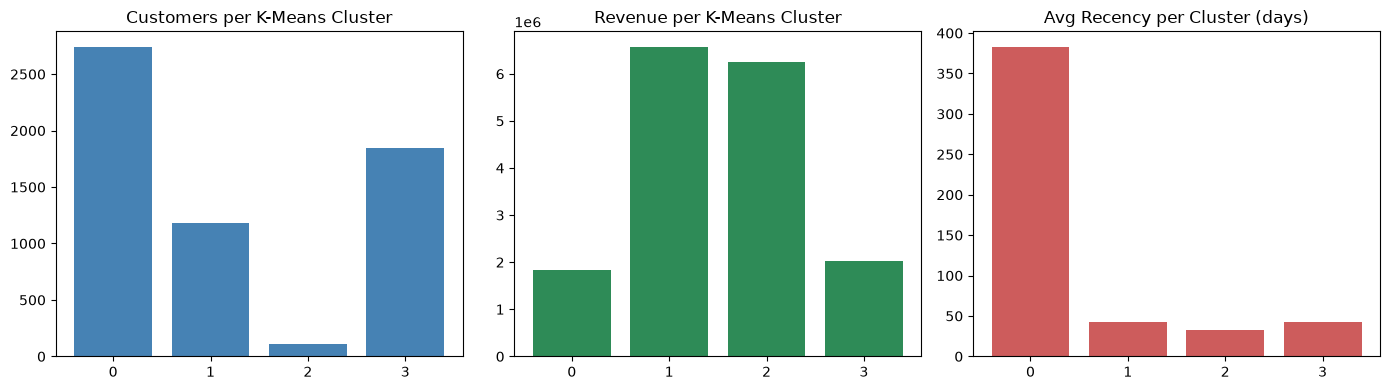

In [22]:
profile_plot = profile.sort_index()
fig, axes = plt.subplots(1, 3, figsize=(14,4))
axes[0].bar(profile_plot.index.astype(str), profile_plot['Customers'], color='steelblue')
axes[0].set_title('Customers per K-Means Cluster')
axes[1].bar(profile_plot.index.astype(str), profile_plot['Total_Revenue'], color='seagreen')
axes[1].set_title('Revenue per K-Means Cluster')
axes[2].bar(profile_plot.index.astype(str), profile_plot['Avg_Recency'], color='indianred')
axes[2].set_title('Avg Recency per Cluster (days)')
plt.tight_layout()
plt.savefig('charts/kmeans_profile_bars.png', bbox_inches='tight')
plt.show()

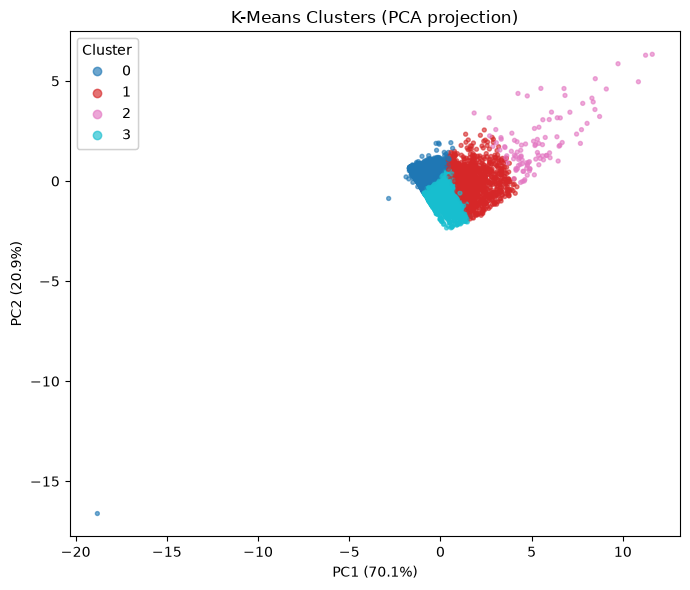

In [23]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(7,6))
scatter = ax.scatter(coords[:,0], coords[:,1], c=rfm['KMeans_Cluster'], cmap='tab10', s=8, alpha=0.6)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('K-Means Clusters (PCA projection)')
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout()
plt.savefig('charts/kmeans_pca_scatter.png', bbox_inches='tight')
plt.show()

### DBSCAN, a second look at outliers

In [24]:
min_samples = 6  # 2 * n_features
nn = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
dist, _ = nn.kneighbors(X_scaled)
k_dist = np.sort(dist[:, -1])
eps = np.percentile(k_dist, 90)

db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
rfm['DBSCAN_Cluster'] = db.labels_

n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise = (db.labels_ == -1).sum()
print(f'eps={eps:.3f} -> {n_clusters} clusters, {n_noise} noise/outlier points ({n_noise/len(db.labels_)*100:.1f}%)')

outliers = rfm[rfm['DBSCAN_Cluster'] == -1]
print()
print('Outlier customers - average Monetary (should be well above typical, confirming these are the same high-value customers K-Means separated):')
print(outliers[['Recency','Frequency','Monetary']].describe())

eps=0.255 -> 13 clusters, 411 noise/outlier points (7.0%)

Outlier customers - average Monetary (should be well above typical, confirming these are the same high-value customers K-Means separated):
          Recency   Frequency       Monetary
count  411.000000  411.000000     411.000000
mean    79.681265   29.783455   21398.549163
std    145.155940   39.035810   49092.353027
min      1.000000    1.000000  -10953.500000
25%      4.000000    9.000000    6061.325000
50%     16.000000   21.000000   10599.420000
75%     74.000000   35.000000   18248.150000
max    692.000000  398.000000  598215.220000


## 8. Customer Lifetime Value: BG/NBD + Gamma-Gamma

I had to fix something first before this would work properly. Some invoices get placed and then fully cancelled by a matching reversal (same customer, exact opposite value). For example, one customer placed an 80,995-unit order worth £168,469.60 that got cancelled the same day, so their real net spend was £2.90. If I don't filter these out, the model treats that fake order as a genuine purchase and the predicted CLV goes haywire; it would push one customer to the single highest CLV in the whole dataset, when in reality they'd barely spent anything. So the cell below finds and removes these fully-reversed invoice pairs before I fit the models. I match at the invoice level (a multi-line cancellation is compared against the full invoice value, not its individual line items) and one-to-one, so a single cancellation can only knock out one sale invoice.

In [25]:
from lifetimes.utils import summary_data_from_transaction_data, calibration_and_holdout_data
from lifetimes import BetaGeoFitter, GammaGammaFitter

sales_all = cust[~cust['IsCancellation']]
cancels_all = cust[cust['IsCancellation']]

invoice_level = sales_all.groupby(['Customer ID','Invoice']).agg(
    InvoiceDate=('InvoiceDate','min'), InvoiceValue=('TotalPrice','sum')
).reset_index()
invoice_level = invoice_level[invoice_level['InvoiceValue'] > 0]

# Aggregate cancellations to invoice level and let each one offset at most one
# sale invoice of the same customer and value (closest in time).
cancel_inv = cancels_all.groupby(['Customer ID','Invoice']).agg(
    CancelDate=('InvoiceDate','min'), CancelValue=('TotalPrice','sum')
).reset_index()
cancel_inv['CancelValue'] = (-cancel_inv['CancelValue']).round(2)

matched = set()
for cid, grp in cancel_inv.groupby('Customer ID'):
    g = invoice_level[invoice_level['Customer ID'] == cid]
    if g.empty:
        continue
    for _, c in grp.sort_values('CancelDate').iterrows():
        cand = g[(~g.index.isin(matched)) & ((g['InvoiceValue'] - c['CancelValue']).abs() < 0.01)]
        if len(cand):
            matched.add((cand['InvoiceDate'] - c['CancelDate']).abs().idxmin())

invoice_level['reversed'] = invoice_level.index.isin(matched)
print('Fully-reversed "fake" sale invoices excluded:', invoice_level['reversed'].sum())
invoice_level_clean = invoice_level[~invoice_level['reversed']].drop(columns=['reversed'])

Fully-reversed "fake" sale invoices excluded: 545


In [26]:
snapshot_date = cust['InvoiceDate'].max() + pd.Timedelta(days=1)
summary = summary_data_from_transaction_data(
    invoice_level_clean, 'Customer ID', 'InvoiceDate',
    monetary_value_col='InvoiceValue', observation_period_end=snapshot_date, freq='D'
)
print('Summary shape:', summary.shape)
summary.describe()

Summary shape: (5847, 4)


,frequency,recency,T,monetary_value
count,5847.000000,5847.000000,5847.000000,5847.000000
mean,4.600650,273.665298,475.204720,290.998859
std,9.897322,258.727013,223.120333,522.300215
min,0.000000,0.000000,1.000000,0.000000
25%,0.000000,0.000000,313.500000,0.000000
50%,2.000000,222.000000,531.000000,216.360000
75%,5.000000,512.000000,669.000000,378.768500
max,247.000000,738.000000,739.000000,21535.900000


In [27]:
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])
print('BG/NBD params:', bgf.params_.to_dict())

repeat = summary[(summary['frequency'] > 0) & (summary['monetary_value'] > 0)]
corr = repeat[['frequency','monetary_value']].corr().iloc[0,1]
print('Frequency-Monetary correlation (should be near 0 for Gamma-Gamma assumption):', round(corr, 4))

ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(repeat['frequency'], repeat['monetary_value'])
print('Gamma-Gamma params:', ggf.params_.to_dict())

BG/NBD params: {'r': 0.6695728375622827, 'alpha': 63.94651678929147, 'a': 0.07521502685993407, 'b': 1.2233648663170322}
Frequency-Monetary correlation (should be near 0 for Gamma-Gamma assumption): 0.1358


Gamma-Gamma params: {'p': 11.707170537233708, 'q': 0.8786744512344526, 'v': 11.706347496040644}


CLV bucket sizes: {'Low': 2923, 'Medium': 1754, 'High': 1170}
Total predicted 6-month revenue by bucket:
CLV_Bucket
High      3329027.10
Low        376873.80
Medium     885713.63
Name: CLV_6m, dtype: float64


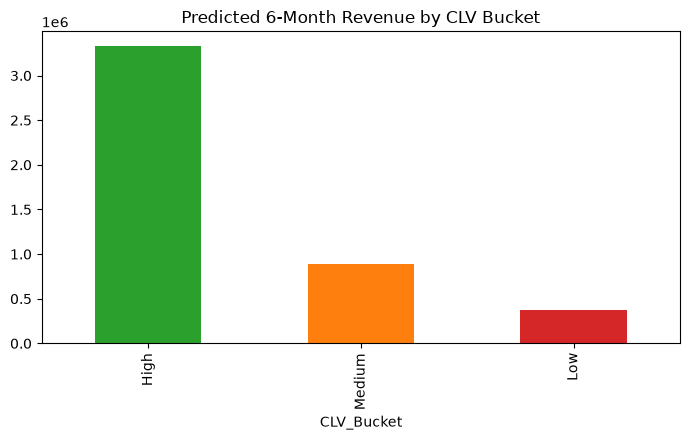

In [28]:
summary['predicted_purchases_6m'] = bgf.predict(180, summary['frequency'], summary['recency'], summary['T'])

summary['expected_avg_value'] = np.nan
summary.loc[repeat.index, 'expected_avg_value'] = ggf.conditional_expected_average_profit(repeat['frequency'], repeat['monetary_value'])
fallback_avg = invoice_level_clean['InvoiceValue'].mean()
summary['expected_avg_value'] = summary['expected_avg_value'].fillna(fallback_avg)

summary['CLV_6m'] = summary['predicted_purchases_6m'] * summary['expected_avg_value']

q80, q50 = summary['CLV_6m'].quantile(0.80), summary['CLV_6m'].quantile(0.50)
summary['CLV_Bucket'] = summary['CLV_6m'].apply(lambda v: 'High' if v>=q80 else ('Medium' if v>=q50 else 'Low'))

print('CLV bucket sizes:', summary['CLV_Bucket'].value_counts().to_dict())
print('Total predicted 6-month revenue by bucket:')
print(summary.groupby('CLV_Bucket')['CLV_6m'].sum().round(2))

fig, ax = plt.subplots(figsize=(7,4.5))
summary.groupby('CLV_Bucket')['CLV_6m'].sum().reindex(['High','Medium','Low']).plot(kind='bar', ax=ax, color=['#2ca02c','#ff7f0e','#d62728'])
ax.set_title('Predicted 6-Month Revenue by CLV Bucket')
plt.tight_layout()
plt.savefig('charts/clv_bucket_bars.png', bbox_inches='tight')
plt.show()

### 8.1 How well does this actually predict? I checked with a calibration / holdout split

In [29]:
min_d, max_d = invoice_level_clean['InvoiceDate'].min(), invoice_level_clean['InvoiceDate'].max()
cal_end = min_d + (max_d - min_d) * 0.75

cal_holdout = calibration_and_holdout_data(
    invoice_level_clean, 'Customer ID', 'InvoiceDate',
    calibration_period_end=cal_end, observation_period_end=max_d + pd.Timedelta(days=1)
)

bgf_cal = BetaGeoFitter(penalizer_coef=0.001)
bgf_cal.fit(cal_holdout['frequency_cal'], cal_holdout['recency_cal'], cal_holdout['T_cal'])
cal_holdout['predicted_holdout'] = bgf_cal.predict(
    (max_d - cal_end).days, cal_holdout['frequency_cal'], cal_holdout['recency_cal'], cal_holdout['T_cal']
)

actual_total = cal_holdout['frequency_holdout'].sum()
predicted_total = cal_holdout['predicted_holdout'].sum()
corr = cal_holdout[['frequency_holdout','predicted_holdout']].corr().iloc[0,1]

print('Actual total holdout purchases:', round(actual_total,1))
print('Predicted total holdout purchases:', round(predicted_total,1))
print(f'Aggregate error: {abs(predicted_total-actual_total)/actual_total*100:.1f}%')
print('Customer-level correlation (actual vs predicted):', round(corr,3))

Actual total holdout purchases: 7836.0
Predicted total holdout purchases: 7683.9
Aggregate error: 1.9%
Customer-level correlation (actual vs predicted): 0.849


## 9. Recommendation System

I built both collaborative filtering and content-based filtering, then blended them into a simple 50/50 hybrid.

### 9.1 First, I built a clean product catalog

In [30]:
non_product_codes2 = non_product_codes + ['TEST001','TEST002']

sales_rs = cust[~cust['IsCancellation']].copy()
sales_rs['StockCode_norm'] = sales_rs['StockCode'].astype(str).str.upper().str.strip()
sales_rs = sales_rs[~sales_rs['StockCode_norm'].isin(non_product_codes2)]

catalog = (sales_rs.groupby(['StockCode_norm','Description']).size().reset_index(name='n')
           .sort_values('n', ascending=False).drop_duplicates('StockCode_norm'))
catalog = catalog[['StockCode_norm','Description']].rename(columns={'StockCode_norm':'StockCode'}).reset_index(drop=True)
print('Catalog size (unique products):', len(catalog))
catalog.head()

Catalog size (unique products): 4620


,StockCode,Description
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER
1,22423,REGENCY CAKESTAND 3 TIER
2,84879,ASSORTED COLOUR BIRD ORNAMENT
3,85099B,JUMBO BAG RED RETROSPOT
4,21034,REX CASH+CARRY JUMBO SHOPPER


### 9.2 Collaborative filtering: item-item similarity

In [31]:
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

inter = sales_rs.groupby(['Customer ID','StockCode_norm'])['Quantity'].sum().reset_index()
inter = inter[inter['Quantity'] > 0]

cust_cat = inter['Customer ID'].astype('category')
item_cat = inter['StockCode_norm'].astype('category')
n_cust, n_items = len(cust_cat.cat.categories), len(item_cat.cat.categories)
print(f'Interaction matrix: {n_cust} customers x {n_items} products, '
      f'{len(inter)/(n_cust*n_items)*100:.2f}% dense')

mat = csr_matrix((inter['Quantity'], (cust_cat.cat.codes, item_cat.cat.codes)), shape=(n_cust, n_items))
item_sim = cosine_similarity(mat.T, dense_output=False)

item_categories = list(item_cat.cat.categories)
cust_categories = list(cust_cat.cat.categories)
print('Item-item similarity matrix shape:', item_sim.shape)

Interaction matrix: 5852 customers x 4620 products, 1.78% dense


Item-item similarity matrix shape: (4620, 4620)


### 9.3 Content-based filtering: product descriptions

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

catalog['Description'] = catalog['Description'].fillna('')
tfidf = TfidfVectorizer(stop_words='english', max_features=3000)
tfidf_matrix = tfidf.fit_transform(catalog['Description'])
content_sim = cosine_similarity(tfidf_matrix, dense_output=False)
print('TF-IDF matrix shape:', tfidf_matrix.shape)

# sanity check
sample_code = catalog[catalog['Description'].str.contains('WHITE HANGING HEART', case=False, na=False)]
if len(sample_code):
    idx = sample_code.index[0]
    sims = content_sim[idx].toarray().flatten()
    top5 = np.argsort(sims)[::-1][1:6]
    print('Products similar to:', catalog.loc[idx,'Description'])
    print(catalog.iloc[top5][['StockCode','Description']])

TF-IDF matrix shape: (4620, 2177)
Products similar to: WHITE HANGING HEART T-LIGHT HOLDER
     StockCode                        Description
19       21733   RED HANGING HEART T-LIGHT HOLDER
53      84970S  HANGING HEART ZINC T-LIGHT HOLDER
2290     85118               HEART T-LIGHT HOLDER
2075     21814              HEART T-LIGHT HOLDER 
65       84978   HANGING HEART JAR T-LIGHT HOLDER


### 9.4 Trying it out on a couple of customers

In [33]:
catalog_idx = catalog.set_index('StockCode')
item_idx_map = {c:i for i,c in enumerate(item_categories)}
cust_idx_map = {c:i for i,c in enumerate(cust_categories)}
content_item_idx = {c:i for i,c in enumerate(catalog['StockCode'])}

def recommend(customer_id, top_n=5, w_collab=0.5, w_content=0.5):
    ci = cust_idx_map[customer_id]
    bought_vec = mat.getrow(ci).toarray().flatten()
    bought_items = [item_categories[i] for i in np.nonzero(bought_vec)[0]]

    collab_scores = np.asarray(bought_vec @ item_sim).flatten()

    content_scores = np.zeros(len(catalog))
    for it in bought_items:
        if it in content_item_idx:
            content_scores += content_sim[content_item_idx[it]].toarray().flatten()
    if bought_items:
        content_scores /= len(bought_items)
    content_scores_aligned = np.array([content_scores[content_item_idx[c]] if c in content_item_idx else 0 for c in item_categories])

    def norm(x):
        rng = x.max() - x.min()
        return (x - x.min()) / rng if rng > 0 else x

    hybrid = w_collab*norm(collab_scores) + w_content*norm(content_scores_aligned)
    hybrid[np.nonzero(bought_vec)[0]] = -1
    top_idx = np.argsort(hybrid)[::-1][:top_n]
    recs = [(item_categories[i], catalog_idx.loc[item_categories[i],'Description'] if item_categories[i] in catalog_idx.index else '?', round(hybrid[i],3)) for i in top_idx]
    return bought_items, recs

import random
random.seed(42)
for cid in random.sample(cust_categories, 2):
    bought, recs = recommend(cid, top_n=5)
    print(f'=== Customer {cid} ===')
    print('Sample purchase history:', [catalog_idx.loc[b,'Description'] if b in catalog_idx.index else b for b in bought[:5]], f'(total {len(bought)} items)')
    print('Top-5 hybrid recommendations:')
    for sc, desc, score in recs:
        print(f'  {sc} | {desc} | score={score}')
    print()

=== Customer 17670 ===
Sample purchase history: ['ICE CREAM DESIGN GARDEN PARASOL', 'SET/4 SKULL BADGES', 'GIRLS VINTAGE TIN SEASIDE BUCKET', 'BOYS VINTAGE TIN SEASIDE BUCKET', 'RED METAL BEACH SPADE '] (total 11 items)
Top-5 hybrid recommendations:
  21749 | LARGE RED RETROSPOT WINDMILL | score=0.787
  21989 | PACK OF 20 SKULL PAPER NAPKINS | score=0.602
  21988 | PACK OF 6 SKULL PAPER PLATES | score=0.602
  21207 | SKULL AND CROSSBONES  GARLAND  | score=0.553
  21250 | SET OF SKULL WALL STICKERS | score=0.496

=== Customer 13274 ===
Sample purchase history: ['SET/5 RED RETROSPOT LID GLASS BOWLS', 'RED RETROSPOT OVEN GLOVE DOUBLE', 'RED SPOTTY APRON ', 'FAIRY CAKE FLANNEL ASSORTED COLOUR', 'RETROSPOT CHILDRENS APRON'] (total 19 items)
Top-5 hybrid recommendations:
  84991 | 60 TEATIME FAIRY CAKE CASES | score=0.804
  84992 | 72 SWEETHEART FAIRY CAKE CASES | score=0.738
  22417 | PACK OF 60 SPACEBOY CAKE CASES | score=0.732
  84990 | 60 GOLD AND SILVER FAIRY CAKE CASES | score=0.657
  

## 10. Summary

- **Data cleaning**: I removed the internal test SKUs and genuine junk rows, kept shipping/fee/admin revenue (it's real money customers paid), and kept cancellations flagged so they net out. Total revenue (ex-cancellations): **£20.97M**.
- **RFM segmentation**: Champions (25.1% of customers) bring in **70.7%** of revenue, a strong Pareto pattern.
- **Clustering**: K-Means (k=4) and DBSCAN agreed with each other, both independently picked out the same small group of very high-value customers.
- **CLV**: I used BG/NBD + Gamma-Gamma, checked it against a calibration/holdout split (1.9% aggregate error, 0.85 correlation at the customer level), and excluded fully-reversed orders that would otherwise inflate individual CLV predictions.
- **Recommendation system**: I combined collaborative and content-based filtering into a hybrid, and the recommendations held up on my spot-checks.

### Open items / things I'd revisit
- Standardizing the 648 StockCodes with inconsistent descriptions, and the 171 case-duplicated StockCodes, at the source
- 12 customers linked to more than one country
- `Unspecified` and `European Community` aren't real countries and inflate the country count
- Whether the hybrid recommendation weighting (currently just 50/50) should be tuned against a held-out purchase set

## 11. Export Deliverables

I save all eight deliverable tables here, so the whole `data/` folder can be rebuilt by just running this notebook (the charts get saved by their own cells above). The master table puts RFM scores, segment, both cluster labels and CLV in one row per customer. 31 customers have no usable purchase history left for the CLV model (every invoice junk or fully reversed), so I give them `CLV_6m = 0` and bucket `Low`.

In [34]:
exports = {
    'cleaned_data': clean,
    'cleaned_data_with_customer': cust,
    'rfm_table': rfm[['Customer ID','Recency','Frequency','Monetary']],
    'rfm_scored': rfm[['Customer ID','Recency','Frequency','Monetary','R_score','F_score','M_score','RFM_score','RFM_sum','Segment']],
    'rfm_clustered': rfm,
    'clv_predictions': summary.reset_index()[['Customer ID','frequency','recency','T','monetary_value','predicted_purchases_6m','expected_avg_value','CLV_6m','CLV_Bucket']],
    'product_catalog': catalog,
}

bg = summary.reset_index().rename(columns={'frequency':'BGNBD_repeat_freq','recency':'BGNBD_recency_days',
                                           'T':'BGNBD_age_days','monetary_value':'BGNBD_avg_order_value'})
master = rfm.merge(bg, on='Customer ID', how='left')
master['gross_vs_net_gap'] = master['BGNBD_repeat_freq']*master['BGNBD_avg_order_value'] - master['Monetary']
no_clv = master['CLV_6m'].isna()
master.loc[no_clv, 'CLV_6m'] = 0.0
master.loc[no_clv, 'CLV_Bucket'] = 'Low'
exports['customer_master_table'] = master

os.makedirs('data', exist_ok=True)
for name, df in exports.items():
    df.to_csv(f'data/{name}.csv', index=False)
    print(f'data/{name}.csv: {len(df):,} rows')

data/cleaned_data.csv: 1,061,150 rows


data/cleaned_data_with_customer.csv: 824,279 rows
data/rfm_table.csv: 5,878 rows
data/rfm_scored.csv: 5,878 rows
data/rfm_clustered.csv: 5,878 rows
data/clv_predictions.csv: 5,847 rows
data/product_catalog.csv: 4,620 rows
data/customer_master_table.csv: 5,878 rows
